# 04 - Hybrid Features (TF-IDF + message statistics)

**Phase 4.** Proposal objective 4: does adding five cheap surface statistics on top of the
lexical features improve spam detection?

The statistics are message length, digit density, punctuation frequency, uppercase ratio and
URL count. They are computed from the **raw** message, because cleaning (lowercasing, stripping
punctuation) is precisely what destroys the signal they measure.

Two arms per model, both at that model's Phase-2 winning representation:

| Arm | Features |
|---|---|
| `text_only` | clean -> vectorize (the Phase-2 recipe, used as a reproducibility control) |
| `hybrid` | the same lexical branch, joined with the five scaled statistics |

**No leakage:** the whole thing is one `Pipeline`/`FeatureUnion` handed to `GridSearchCV`, so
the vectorizer *and* the `MinMaxScaler` on the statistics are fitted on the training folds only.
The statistics are never computed or scaled over the full dataset.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # precede numpy/xgboost import: avoids OpenMP deadlock

import sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import load_dataset, make_split
from src.features import bow, tfidf_unigram, tfidf_ngram, lexical_pipeline, hybrid, StatisticalFeatures
from src.models import get_models
from src.evaluation import run_master_grid

sns.set_theme(style="whitegrid")
RESULTS = config.RESULTS_DIR
np.random.seed(config.RANDOM_SEED)
print("Results dir:", RESULTS)

Results dir: /home/sdd/Documents/ovi/final year project/results


## 1. Load the data and reuse the persisted split

Two guards before any modelling, so a silent upstream change fails loudly here rather than
showing up later as an unexplained metric drift:

1. the row count must equal what notebook 01 persisted (`rows_dedup` in `eda_summary.csv`);
2. the split is **reloaded** from `results/split_indices.npz`, never regenerated.

Note that this notebook keeps `X_train` / `X_test` as **raw** text. Notebooks 02 and 03 cleaned
up front; here cleaning happens inside the pipeline so the statistical branch can still see the
original capitals and punctuation.

In [2]:
df = load_dataset()

eda = pd.read_csv(RESULTS / "eda_summary.csv").iloc[0]
assert len(df) == int(eda["rows_dedup"]), (
    f"row count changed: {len(df)} != {int(eda['rows_dedup'])} from eda_summary.csv"
)

X_train, X_test, y_train, y_test = make_split(df)   # reloads results/split_indices.npz
assert config.SPLIT_PATH.exists(), "the persisted split is missing - do not re-split here"

scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"rows={len(df)}  train={len(X_train)}  test={len(X_test)}")
print(f"train spam%={100*y_train.mean():.2f}  test spam%={100*y_test.mean():.2f}")
print(f"scale_pos_weight={scale_pos_weight:.3f}")
print("\nRaw (uncleaned) training example:")
print(" ", X_train[0][:120])

rows=5158  train=4126  test=1032
train spam%=12.46  test spam%=12.40
scale_pos_weight=7.027

Raw (uncleaned) training example:
  Call him and say you not coming today ok and tell them not to fool me like this ok


## 2. What the five statistics actually measure

A quick look before using them: one obvious spam-shaped string and one ordinary message, so the
numbers can be sanity-checked by eye rather than trusted blindly.

In [3]:
demo = [
    "WIN a FREE prize!! Txt WIN to 80086 now www.claim-now.com",
    "ok lah... see you at the library around 4 then",
]
stat_demo = pd.DataFrame(
    StatisticalFeatures().transform(demo),
    columns=list(StatisticalFeatures.FEATURE_NAMES),
    index=["spam-shaped", "ham-shaped"],
)
stat_demo.round(4)

,char_len,digit_density,punct_freq,upper_ratio,url_count
spam-shaped,57.0,0.0877,0.0877,0.2895,1.0
ham-shaped,46.0,0.0217,0.0652,0.0000,0.0


## 3. Each model's Phase-2 winning representation

Read from `results/master_metrics.csv` rather than hard-coded, so the two phases cannot drift
apart. Each model is held at its own best representation while the feature set is varied - the
same "change one thing at a time" discipline used in the Phase-3 ablation.

In [4]:
mm = pd.read_csv(RESULTS / "master_metrics.csv")
best_rep = mm.loc[mm.groupby("model")["f1"].idxmax()].set_index("model")

MIN_DF = 2
VECTORIZERS = {
    "bow":           lambda: bow(min_df=MIN_DF),
    "tfidf_unigram": lambda: tfidf_unigram(min_df=MIN_DF),
    "tfidf_bigram":  lambda: tfidf_ngram(max_n=2, min_df=MIN_DF),
    "tfidf_trigram": lambda: tfidf_ngram(max_n=3, min_df=MIN_DF),
}
models_all = get_models(scale_pos_weight=scale_pos_weight)
MODEL_ORDER = ["MultinomialNB", "LogisticRegression", "LinearSVM", "XGBoost"]

print("Phase-2 winning representation per model (the fixed lexical baseline for this phase):")
for name in MODEL_ORDER:
    r = best_rep.loc[name]
    print(f"  {name:20s} {r['representation']:14s} F1={r['f1']:.4f}  FPR={r['fpr']:.4f}")

Phase-2 winning representation per model (the fixed lexical baseline for this phase):
  MultinomialNB        bow            F1=0.9317  FPR=0.0055
  LogisticRegression   tfidf_bigram   F1=0.9444  FPR=0.0055
  LinearSVM            tfidf_unigram  F1=0.9482  FPR=0.0044
  XGBoost              bow            F1=0.9274  FPR=0.0055


## 4. Shape gate: the hybrid matrix must be exactly five columns wider

A mis-wired `FeatureUnion` is the easy way to get plausible-looking but meaningless results, so
check the width directly before running anything expensive. The statistics must also stay
non-negative after scaling on unseen data, or MultinomialNB will refuse to predict - which is
why `MinMaxScaler(clip=True)` is used.

In [5]:
for name in MODEL_ORDER:
    rep = best_rep.loc[name, "representation"]
    lex = lexical_pipeline(VECTORIZERS[rep]())
    hyb = hybrid(VECTORIZERS[rep]())
    n_lex = lex.fit_transform(X_train).shape[1]
    n_hyb = hyb.fit_transform(X_train).shape[1]
    test_min = hyb.transform(X_test).min()
    assert n_hyb == n_lex + 5, f"{name}: hybrid width {n_hyb} != {n_lex} + 5"
    assert test_min >= 0.0, f"{name}: negative feature value {test_min} would break MultinomialNB"
    print(f"  {name:20s} {rep:14s} lexical={n_lex:6d}  hybrid={n_hyb:6d}  (+5)  test min={test_min:.1f}  OK")

  MultinomialNB        bow            lexical=  3183  hybrid=  3188  (+5)  test min=0.0  OK


  LogisticRegression   tfidf_bigram   lexical=  9622  hybrid=  9627  (+5)  test min=0.0  OK


  LinearSVM            tfidf_unigram  lexical=  3183  hybrid=  3188  (+5)  test min=0.0  OK


  XGBoost              bow            lexical=  3183  hybrid=  3188  (+5)  test min=0.0  OK


## 5. Run both arms

`run_master_grid` is reused unchanged, one model at a time (each model has a different
representation, so the full cross-product would be wrong here). Every configuration is still
tuned by stratified 5-fold CV on the training set and evaluated **once** on the held-out test
set.

`n_jobs=1` is deliberate: XGBoost is back in this phase, and its OpenMP threads deadlock against
joblib's process pool. `src/config.py` already pins `OMP_NUM_THREADS=1`, which covers the
OpenMP side only.

In [6]:
cv = config.get_cv(5)
rows, fitted_all = [], {}

for arm, build in [("text_only", lexical_pipeline), ("hybrid", hybrid)]:
    for name in MODEL_ORDER:
        rep = best_rep.loc[name, "representation"]
        make_features = (lambda b=build, r=rep: b(VECTORIZERS[r]()))
        res, fitted = run_master_grid(
            {name: models_all[name]},
            {rep: make_features},
            X_train, y_train, X_test, y_test, cv, n_jobs=1,
        )
        est = fitted[(name, rep)]
        res["feature_set"] = arm
        res["n_features"] = est[:-1].transform(X_train[:1]).shape[1]
        rows.append(res)
        fitted_all[(name, arm)] = est

hdf = pd.concat(rows, ignore_index=True)
print(f"\n{len(hdf)} rows ({len(MODEL_ORDER)} models x 2 feature sets)")

[ 1/1] bow            MultinomialNB        F1=0.9317 FPR=0.0055 (2.6s)


[ 1/1] tfidf_bigram   LogisticRegression   F1=0.9444 FPR=0.0055 (3.2s)


[ 1/1] tfidf_unigram  LinearSVM            F1=0.9482 FPR=0.0044 (2.3s)


[ 1/1] bow            XGBoost              F1=0.9274 FPR=0.0055 (28.1s)


[ 1/1] bow            MultinomialNB        F1=0.9398 FPR=0.0044 (4.5s)


[ 1/1] tfidf_bigram   LogisticRegression   F1=0.9528 FPR=0.0055 (4.8s)


[ 1/1] tfidf_unigram  LinearSVM            F1=0.9486 FPR=0.0055 (3.7s)


[ 1/1] bow            XGBoost              F1=0.9412 FPR=0.0077 (35.5s)



8 rows (4 models x 2 feature sets)


## 6. Reproducibility gate: the `text_only` arm must reproduce Phase 2 exactly

The `text_only` arm is the Phase-2 recipe rebuilt a different way - cleaning moved inside the
pipeline instead of being applied beforehand. It is therefore a control, not a new experiment,
and it must land on the identical number. If it does not, the refactor changed the meaning of
the pipeline and the hybrid comparison is not trustworthy.

In [7]:
METRICS = ["accuracy", "precision", "recall", "f1", "fpr", "auc", "cv_best_f1", "tp", "fp", "tn", "fn"]
control = hdf[hdf.feature_set == "text_only"].set_index("model")

drift = []
for name in MODEL_ORDER:
    want = best_rep.loc[name]
    got = control.loc[name]
    bad = [m for m in METRICS if abs(float(got[m]) - float(want[m])) > 1e-12]
    status = "reproduces Phase 2" if not bad else f"DRIFT in {bad}"
    drift += bad
    print(f"  {name:20s} F1={got['f1']:.4f} (Phase 2: {want['f1']:.4f})  {status}")

assert not drift, f"text_only arm does not reproduce Phase 2: {sorted(set(drift))}"
print("\nAll four control rows reproduce master_metrics.csv to full float precision.")

  MultinomialNB        F1=0.9317 (Phase 2: 0.9317)  reproduces Phase 2
  LogisticRegression   F1=0.9444 (Phase 2: 0.9444)  reproduces Phase 2
  LinearSVM            F1=0.9482 (Phase 2: 0.9482)  reproduces Phase 2
  XGBoost              F1=0.9274 (Phase 2: 0.9274)  reproduces Phase 2

All four control rows reproduce master_metrics.csv to full float precision.


## 7. Save the comparison table

In [8]:
col_order = ["model", "representation", "feature_set", "n_features",
             "accuracy", "precision", "recall", "f1", "fpr", "auc", "cv_best_f1",
             "tp", "fp", "tn", "fn", "best_params"]
to_save = hdf.copy()
to_save["best_params"] = to_save["best_params"].astype(str)
to_save = to_save[col_order].sort_values(["model", "feature_set"]).reset_index(drop=True)
to_save.to_csv(RESULTS / "hybrid_comparison.csv", index=False)
print("Saved results/hybrid_comparison.csv")

to_save[["model", "representation", "feature_set", "n_features", "f1", "fpr", "auc"]].round(4)

Saved results/hybrid_comparison.csv


,model,representation,feature_set,n_features,f1,fpr,auc
0,LinearSVM,tfidf_unigram,hybrid,3188,0.9486,0.0055,0.9971
1,LinearSVM,tfidf_unigram,text_only,3183,0.9482,0.0044,0.9886
2,LogisticRegression,tfidf_bigram,hybrid,9627,0.9528,0.0055,0.9980
3,LogisticRegression,tfidf_bigram,text_only,9622,0.9444,0.0055,0.9930
4,MultinomialNB,bow,hybrid,3188,0.9398,0.0044,0.9803
5,MultinomialNB,bow,text_only,3183,0.9317,0.0055,0.9773
6,XGBoost,bow,hybrid,3188,0.9412,0.0077,0.9974
7,XGBoost,bow,text_only,3183,0.9274,0.0055,0.9807


## 8. Lift figure

F1 (higher is better) and FPR (lower is better) side by side, `text_only` against `hybrid` for
each model.

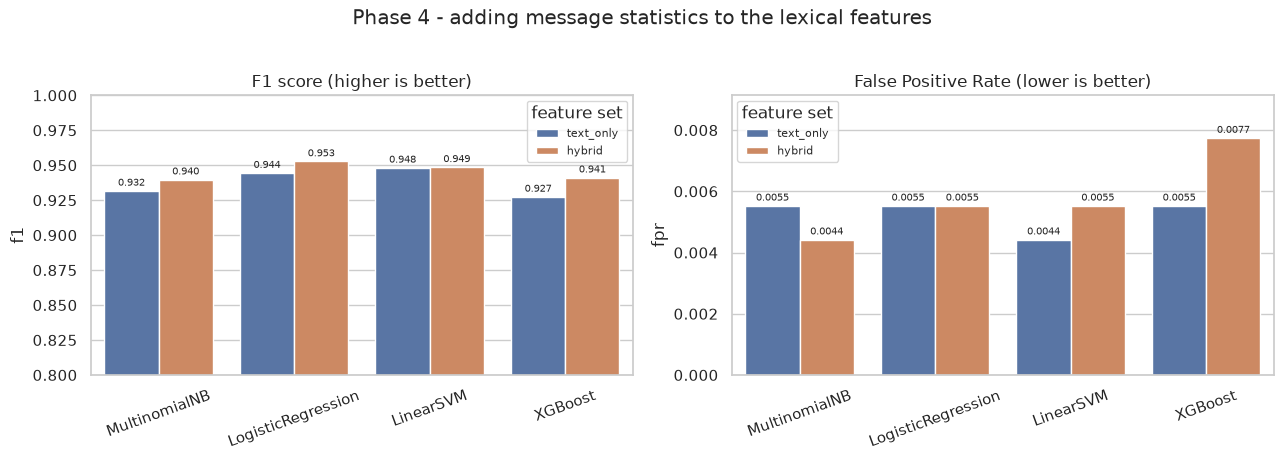

In [9]:
plot_df = hdf.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=MODEL_ORDER, ordered=True)
plot_df = plot_df.sort_values(["model", "feature_set"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title, better in [
    (axes[0], "f1", "F1 score (higher is better)", "max"),
    (axes[1], "fpr", "False Positive Rate (lower is better)", "min"),
]:
    sns.barplot(data=plot_df, x="model", y=metric, hue="feature_set",
                hue_order=["text_only", "hybrid"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.4f" if metric == "fpr" else "%.3f", fontsize=7, padding=2)
    ax.margins(y=0.18)
    ax.legend(title="feature set", fontsize=8)

axes[0].set_ylim(0.80, 1.0)
fig.suptitle("Phase 4 - adding message statistics to the lexical features", y=1.02)
fig.tight_layout()
fig.savefig(RESULTS / "fig_hybrid_lift.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Per-model takeaway

The lift is the hybrid arm minus the control arm. A change smaller than 0.002 F1 is called
neutral - on a 1,032-message test set that is well inside the noise a single reclassified
message can produce.

In [10]:
EPS = 0.002
summary = []
for name in MODEL_ORDER:
    t = hdf[(hdf.model == name) & (hdf.feature_set == "text_only")].iloc[0]
    h = hdf[(hdf.model == name) & (hdf.feature_set == "hybrid")].iloc[0]
    d_f1, d_fpr = h["f1"] - t["f1"], h["fpr"] - t["fpr"]
    verdict = "helped" if d_f1 > EPS else ("hurt" if d_f1 < -EPS else "neutral")
    summary.append({
        "model": name, "representation": t["representation"],
        "f1_text_only": round(t["f1"], 4), "f1_hybrid": round(h["f1"], 4),
        "f1_lift": round(d_f1, 4),
        "fpr_text_only": round(t["fpr"], 4), "fpr_hybrid": round(h["fpr"], 4),
        "fpr_change": round(d_fpr, 4), "verdict": verdict,
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print()
for r in summary:
    arrow = "up" if r["f1_lift"] > 0 else ("down" if r["f1_lift"] < 0 else "flat")
    print(f"{r['model']:20s} F1 {r['f1_text_only']:.4f} -> {r['f1_hybrid']:.4f} "
          f"({arrow} {abs(r['f1_lift']):.4f}) : {r['verdict']}")
summary_df

             model representation  f1_text_only  f1_hybrid  f1_lift  fpr_text_only  fpr_hybrid  fpr_change verdict
     MultinomialNB            bow        0.9317     0.9398   0.0080         0.0055      0.0044     -0.0011  helped
LogisticRegression   tfidf_bigram        0.9444     0.9528   0.0083         0.0055      0.0055      0.0000  helped
         LinearSVM  tfidf_unigram        0.9482     0.9486   0.0004         0.0044      0.0055      0.0011 neutral
           XGBoost            bow        0.9274     0.9412   0.0138         0.0055      0.0077      0.0022  helped

MultinomialNB        F1 0.9317 -> 0.9398 (up 0.0080) : helped
LogisticRegression   F1 0.9444 -> 0.9528 (up 0.0083) : helped
LinearSVM            F1 0.9482 -> 0.9486 (up 0.0004) : neutral
XGBoost              F1 0.9274 -> 0.9412 (up 0.0138) : helped


,model,representation,f1_text_only,f1_hybrid,f1_lift,fpr_text_only,fpr_hybrid,fpr_change,verdict
0,MultinomialNB,bow,0.9317,0.9398,0.0080,0.0055,0.0044,-0.0011,helped
1,LogisticRegression,tfidf_bigram,0.9444,0.9528,0.0083,0.0055,0.0055,0.0000,helped
2,LinearSVM,tfidf_unigram,0.9482,0.9486,0.0004,0.0044,0.0055,0.0011,neutral
3,XGBoost,bow,0.9274,0.9412,0.0138,0.0055,0.0077,0.0022,helped
